In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.getcwd()

'c:\\Users\\Usuario\\OneDrive\\Desktop\\Proyecto\\mlops_pipeline\\mlops_pipeline\\notebooks'

In [4]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "Base_de_datos.xlsx"

print("Ruta usada:", DATA_PATH)

df = pd.read_excel(DATA_PATH)

print("Dataset cargado correctamente")
print(df.shape)
df.head()

Ruta usada: c:\Users\Usuario\OneDrive\Desktop\Proyecto\mlops_pipeline\mlops_pipeline\data\raw\Base_de_datos.xlsx
Dataset cargado correctamente
(10763, 23)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [5]:
#Exploracion Inicial
df.dtypes

tipo_credito                              int64
fecha_prestamo                   datetime64[ns]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                             object
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos_datacredito           

In [6]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

Numéricas: 20
Categóricas: 2


In [7]:
df.columns.tolist()

['tipo_credito',
 'fecha_prestamo',
 'capital_prestado',
 'plazo_meses',
 'edad_cliente',
 'tipo_laboral',
 'salario_cliente',
 'total_otros_prestamos',
 'cuota_pactada',
 'puntaje',
 'puntaje_datacredito',
 'cant_creditosvigentes',
 'huella_consulta',
 'saldo_mora',
 'saldo_total',
 'saldo_principal',
 'saldo_mora_codeudor',
 'creditos_sectorFinanciero',
 'creditos_sectorCooperativo',
 'creditos_sectorReal',
 'promedio_ingresos_datacredito',
 'tendencia_ingresos',
 'Pago_atiempo']

In [8]:
#Definicion de variable objetivo
TARGET = "Pago_atiempo"
assert TARGET in df.columns, f"Target '{TARGET}' no existe. Columnas: {df.columns.tolist()}"

In [9]:
df["Pago_atiempo"].value_counts(normalize=True)

Pago_atiempo
1    0.952523
0    0.047477
Name: proportion, dtype: float64

La variable pago_a_tiempo presenta un desbalance significativo:

95.25% de los clientes pagan a tiempo.

4.75% de los clientes no pagan a tiempo.

Este comportamiento es esperable en contextos financieros, donde la mayoría de clientes cumplen con sus obligaciones.

Sin embargo, este desbalance deberá considerarse en etapas posteriores de modelado, ya que un modelo que prediga siempre la clase mayoritaria podría alcanzar una alta accuracy pero bajo poder predictivo sobre la clase minoritaria (clientes con riesgo).

Por ello, se priorizarán métricas como Recall, F1-score y PR-AUC, además del uso de técnicas como class_weight o ajuste de umbral de decisión.

ANALISIS UNIVARIBLE

In [10]:
#NUMERICAS
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tipo_credito,10763.0,5.411131e+00,2.338279e+00,4.00000,4.000000e+00,4.000000e+00,9.000000e+00,6.800000e+01
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10
total_otros_prestamos,10763.0,6.238870e+06,1.184183e+08,0.00000,5.000000e+05,1.000000e+06,2.000000e+06,6.787675e+09
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01
puntaje_datacredito,10757.0,7.807908e+02,1.048780e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01


<Figure size 1500x1000 with 0 Axes>

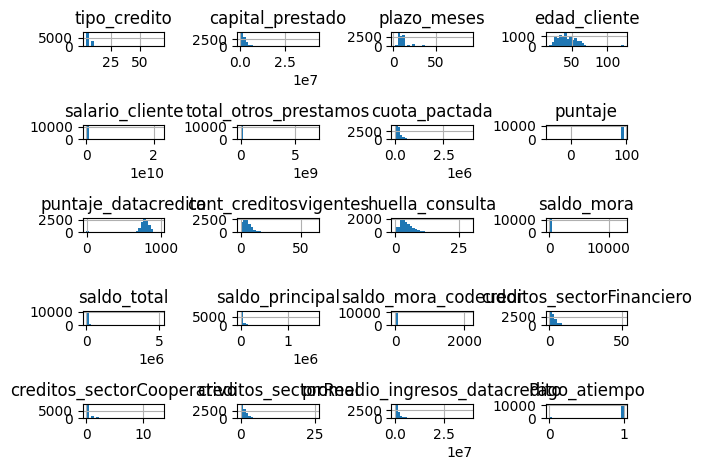

In [11]:
plt.figure(figsize=(15,10))
df[num_cols].hist(bins=30)
plt.tight_layout()
plt.show()

Observaciones sobre las distribuciones

La mayoría de las variables financieras presentan distribuciones altamente asimétricas con colas largas hacia valores altos.

Se observan posibles outliers en variables monetarias como capital_prestado, saldo_total y salario_cliente.

Las variables tipo conteo muestran concentración en valores bajos con dispersión moderada.

No se observa una distribución normal predominante, lo cual sugiere que en etapas posteriores podrían aplicarse técnicas de escalado o transformaciones logarítmicas.

In [12]:
TARGET = "pago_atiempo"

# por si quedaron columnas con mayúsculas/espacios
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace("-", "_")
)

assert TARGET in df.columns, f"No existe {TARGET}. Columnas: {df.columns.tolist()}"

# recalcular columnas numéricas correctamente
num_cols = df.select_dtypes(include=["int64","float64","int32","float32"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object","category","bool"]).columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))
print("Target dtype:", df[TARGET].dtype)

Numéricas: 20
Categóricas: 2
Target dtype: int64


In [13]:
#Correlacion con el Target
corr_with_target = df[num_cols].corrwith(df[TARGET])
corr_with_target = corr_with_target.sort_values(ascending=False)

corr_with_target

pago_atiempo                     1.000000
puntaje                          0.923134
puntaje_datacredito              0.067882
promedio_ingresos_datacredito    0.039867
edad_cliente                     0.032252
creditos_sectorfinanciero        0.021390
creditos_sectorcooperativo       0.021267
saldo_total                      0.014364
saldo_principal                  0.011473
cant_creditosvigentes            0.008829
saldo_mora_codeudor              0.002631
tipo_credito                     0.000951
salario_cliente                 -0.003981
total_otros_prestamos           -0.010041
cuota_pactada                   -0.011814
creditos_sectorreal             -0.023306
capital_prestado                -0.040624
plazo_meses                     -0.063105
saldo_mora                      -0.073458
huella_consulta                 -0.073737
dtype: float64

Hallazgo relevante: posible variable dominante

Se observa una correlación extremadamente alta (0.92) entre la variable puntaje y la variable objetivo pago_atiempo.

Este nivel de correlación sugiere que:

La variable puntaje podría ser altamente predictiva.

Podría existir riesgo de fuga de información (data leakage) si el puntaje fue calculado utilizando información posterior al evento de pago.

En una etapa posterior se deberá evaluar el modelo con y sin esta variable para verificar su impacto real.

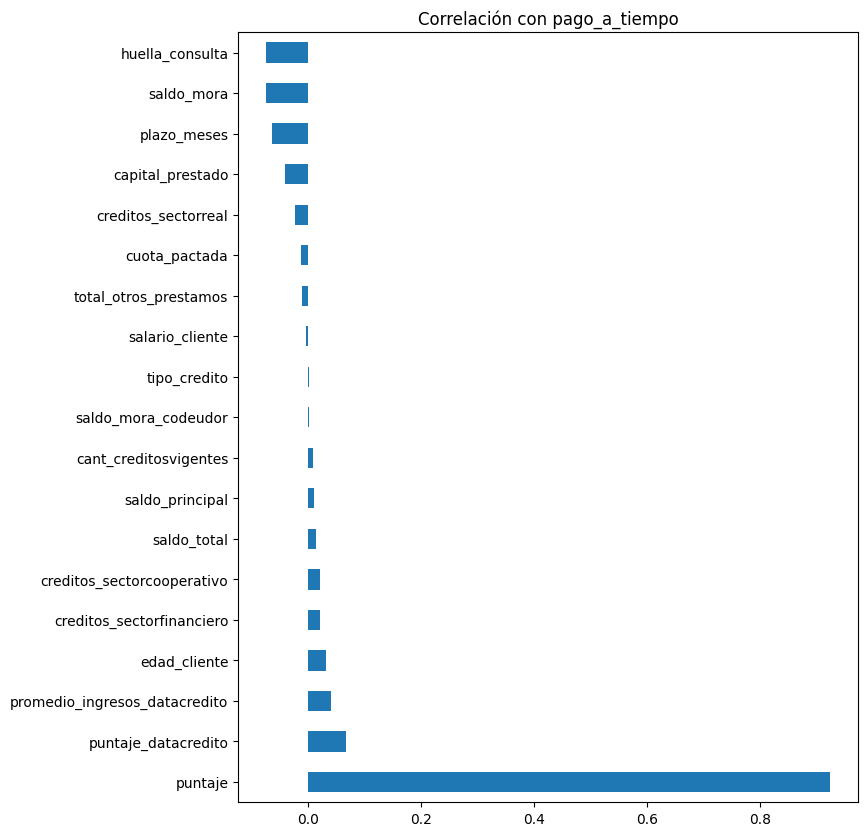

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,10))
corr_with_target.drop(TARGET).plot(kind="barh")
plt.title("Correlación con pago_a_tiempo")
plt.show()

In [15]:
#Categoricas
for col in cat_cols:
    print(df[col].value_counts(normalize=True))
    print("\n")

tipo_laboral
Empleado         0.62752
Independiente    0.37248
Name: proportion, dtype: float64


tendencia_ingresos
Creciente      0.676031
Decreciente    0.164858
Estable        0.151705
0              0.000894
8315           0.000766
1000000        0.000511
9147           0.000255
75761          0.000128
-164315        0.000128
2029000        0.000128
17181          0.000128
15245          0.000128
82657          0.000128
52862          0.000128
1817052        0.000128
15090          0.000128
146918         0.000128
1123000        0.000128
10808          0.000128
4250635        0.000128
22363          0.000128
-101368        0.000128
86286          0.000128
65988          0.000128
77975          0.000128
-288           0.000128
22832          0.000128
5697           0.000128
122727         0.000128
158042         0.000128
3978           0.000128
168750         0.000128
-28589         0.000128
-566272        0.000128
24702          0.000128
31837          0.000128
417087         0.00

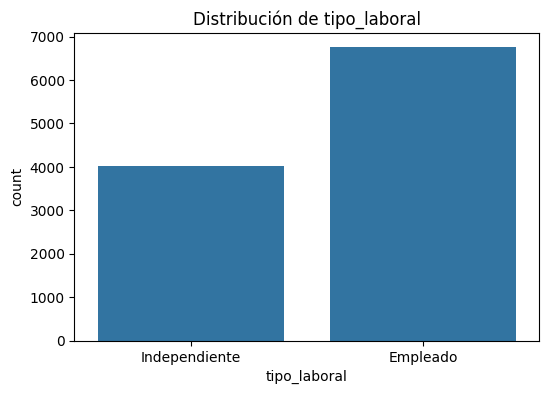

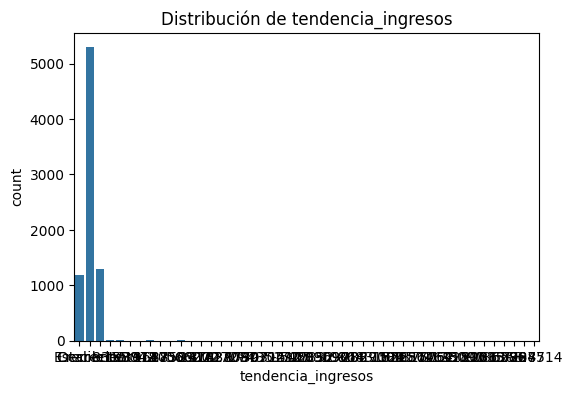

In [16]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribución de {col}")
    plt.show()

Análisis Bivariable

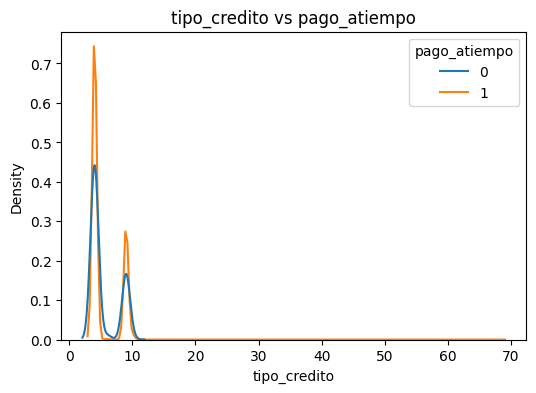

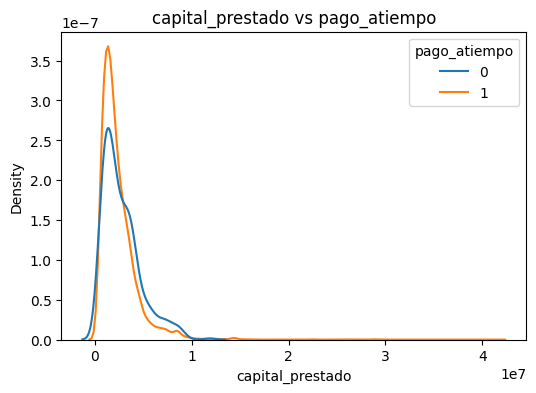

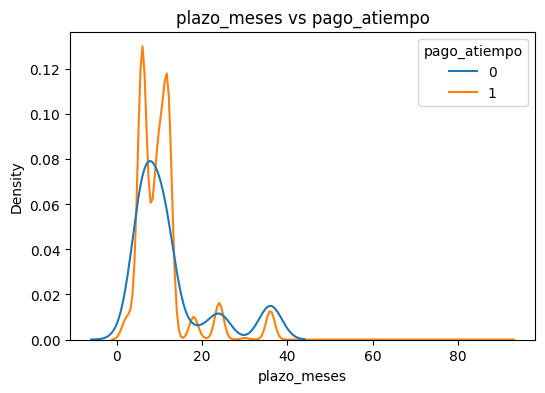

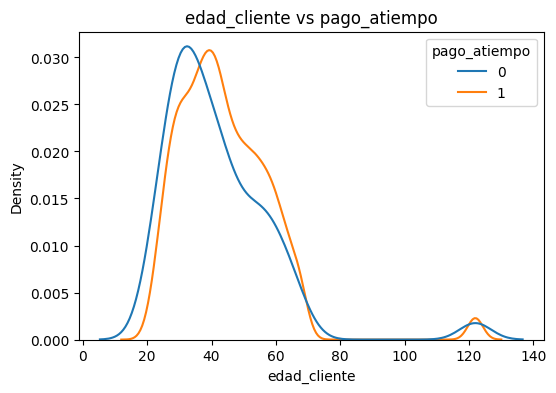

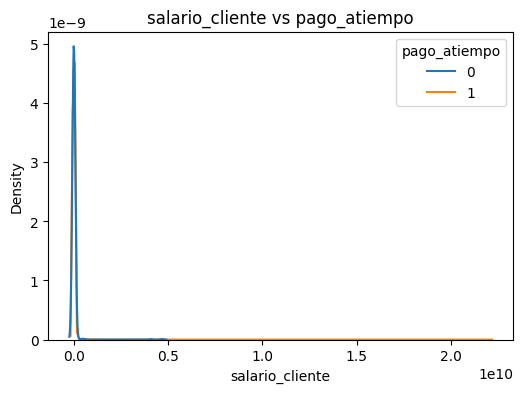

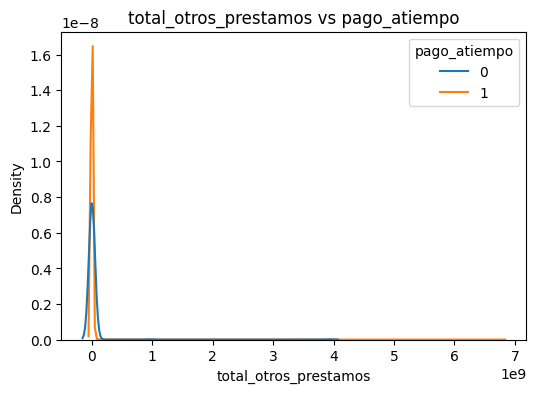

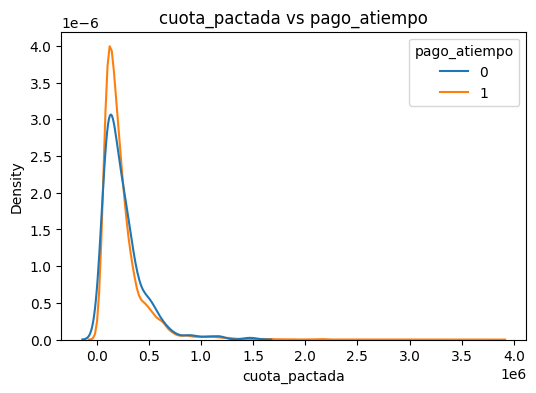

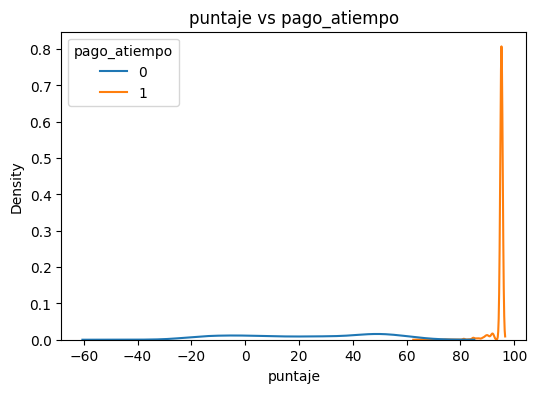

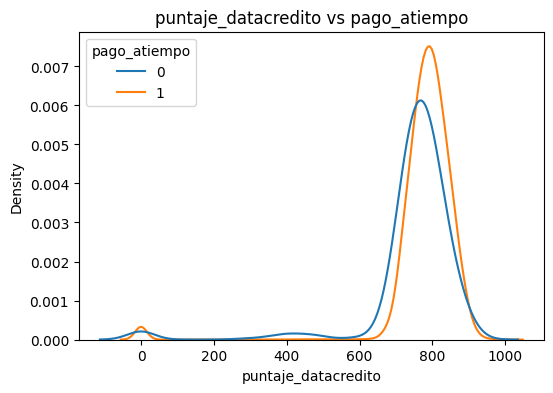

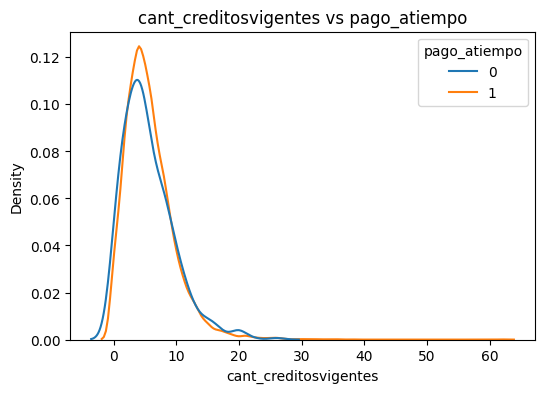

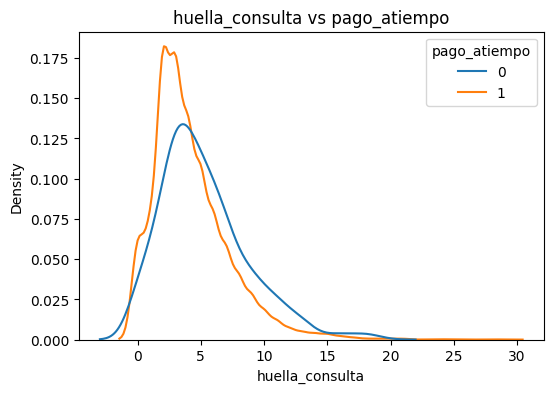

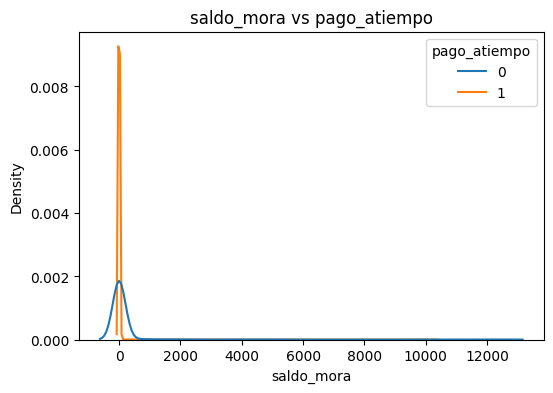

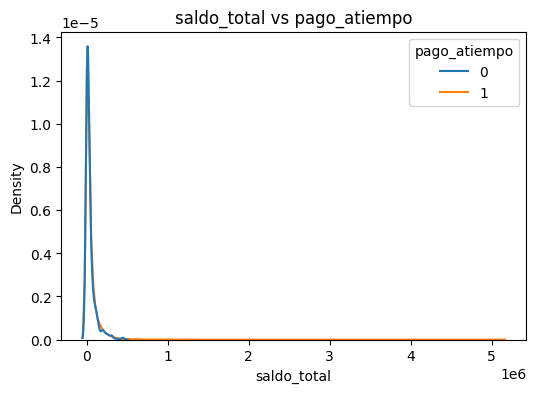

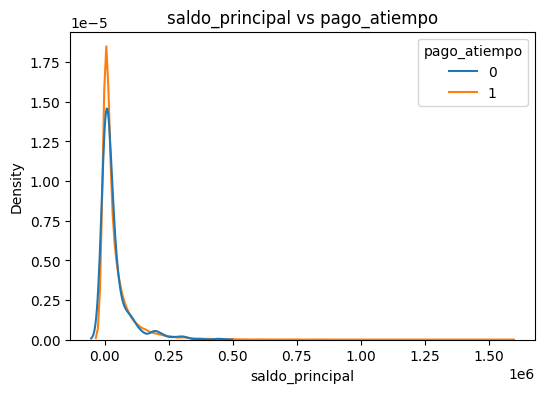

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9360\27541202.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col, hue="pago_atiempo", common_norm=False)


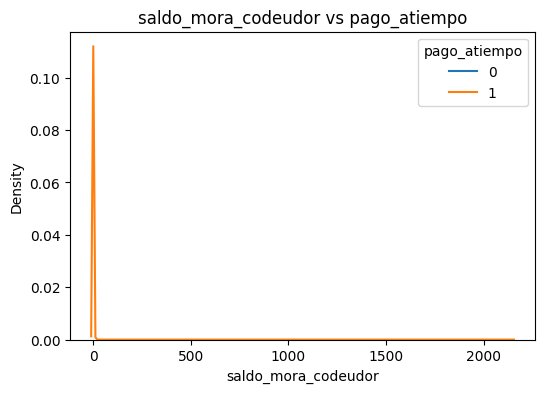

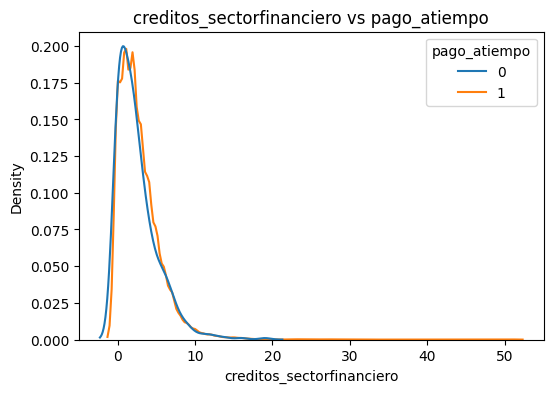

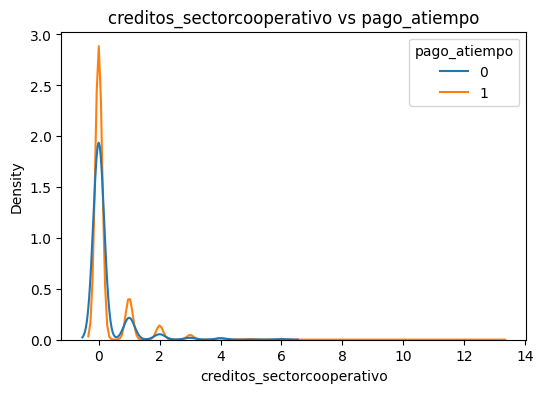

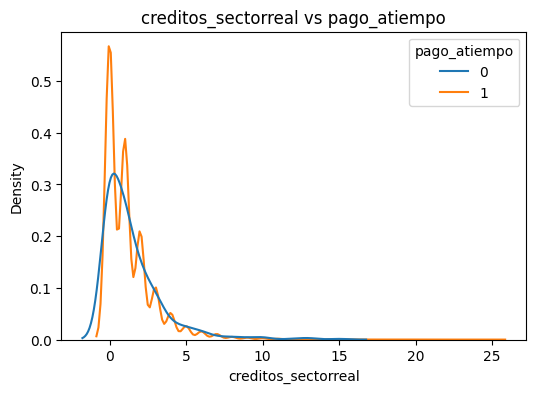

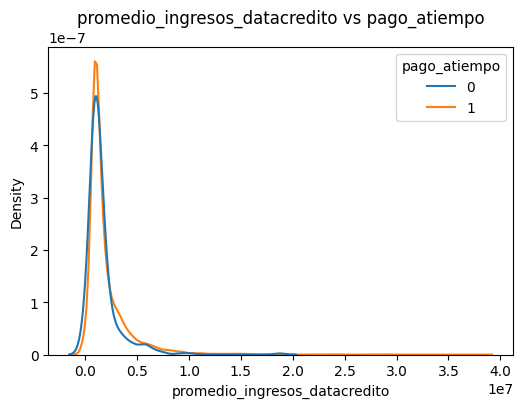

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9360\27541202.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col, hue="pago_atiempo", common_norm=False)


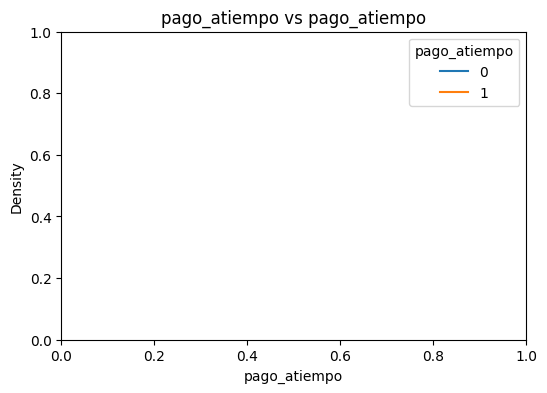

In [17]:
#Numéricas vs pago_a_tiempo
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue="pago_atiempo", common_norm=False)
    plt.title(f"{col} vs pago_atiempo")
    plt.show()

Multivariable

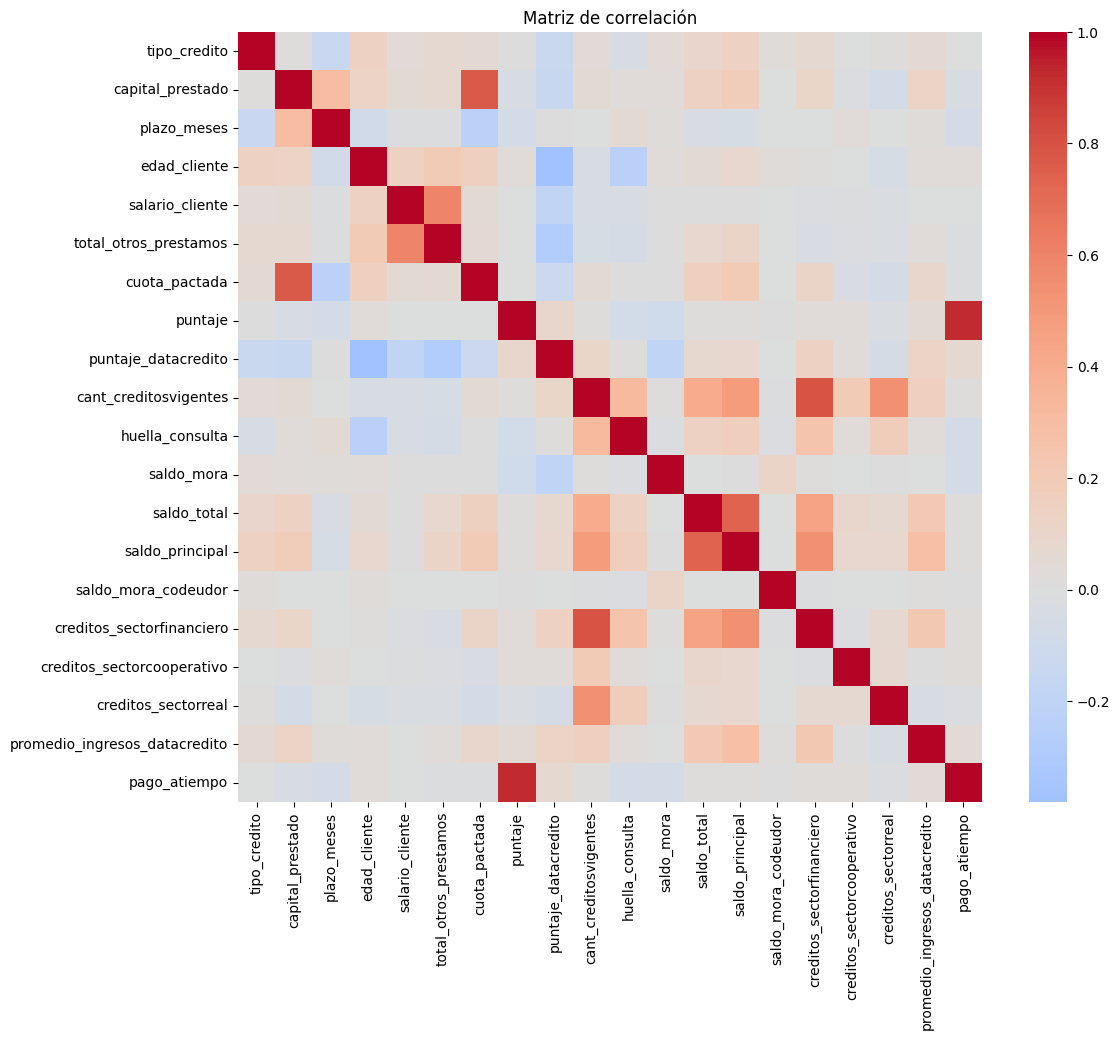

In [18]:
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

**Conclusiones del Análisis Exploratorio (EDA)**

# Estructura del dataset

El dataset está compuesto por 20 variables numéricas y 2 categóricas.

No se detectaron inconsistencias estructurales graves.

Las variables financieras presentan escalas muy diferentes, lo cual sugiere que en etapas posteriores podría requerirse escalado o normalización.

# Distribución de la variable objetivo

La variable pago_atiempo presenta un desbalance significativo:

95.25% de los clientes pagan a tiempo.

4.75% no pagan a tiempo.

Este comportamiento es coherente con escenarios financieros reales, donde la mayoría de clientes cumplen sus obligaciones.

Sin embargo, este desbalance implica que la métrica Accuracy no será suficiente para evaluar modelos futuros.
Se priorizarán métricas como:

Recall (clase minoritaria)

F1-score

PR-AUC

Matriz de confusión

# Distribución de variables numéricas

La mayoría de variables financieras presentan asimetría positiva (right-skewed).

Se observan posibles outliers en variables monetarias como:

capital_prestado

saldo_total

salario_cliente

Esto sugiere que podrían evaluarse transformaciones logarítmicas o modelos menos sensibles a escala (árboles).

# Relación entre variables y el target

Se identificó una correlación extremadamente alta entre:

puntaje → 0.92 con pago_a_tiempo

Este hallazgo sugiere que:

La variable puntaje podría ser altamente predictiva.

Existe riesgo potencial de data leakage, si dicho puntaje fue construido utilizando información relacionada con el comportamiento de pago.

En etapas posteriores se evaluará el desempeño del modelo con y sin esta variable para validar su impacto real.

También se observaron correlaciones negativas moderadas en variables como:

saldo_mora

huella_consulta

plazo_meses

Lo cual es coherente con mayor riesgo de incumplimiento.

# Multicolinealidad

Se observan relaciones esperables entre variables financieras relacionadas con saldos (saldo_total, saldo_principal, etc.), aunque no se identifican correlaciones extremas que impidan modelado inicial.

Reglas preliminares de validación de datos

A partir del análisis exploratorio se proponen las siguientes reglas:

Edad mínima ≥ 18 años.

Ingresos y capital prestado no pueden ser negativos.

No se permiten valores futuros en columnas de fecha (si aplica).

Variables categóricas deben pertenecer a dominios definidos.

Columnas con alto porcentaje de nulos deben evaluarse antes del modelado.

Detección y tratamiento de outliers en variables monetarias.

# Consideraciones para la siguiente etapa

Para el entrenamiento del modelo se deberá considerar:

Manejo del desbalance mediante class_weight o técnicas equivalentes.

Evaluación con métricas robustas.

Posible escalado de variables.

Evaluación del impacto de variables altamente correlacionadas.

In [19]:
df["tipo_credito"].unique()
df["tipo_credito"].nunique()
df

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorfinanciero,creditos_sectorcooperativo,creditos_sectorreal,promedio_ingresos_datacredito,tendencia_ingresos,pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10758,9,2025-01-19 16:18:28,2414886.0,10,29,Independiente,3000000,300000,204819,13.134355,...,172.0,1112.0,1112.0,NaN,0,0,1,NaN,NaN,0
10759,4,2025-01-10 16:40:21,2916000.0,24,27,Empleado,2500000,400000,127460,55.973342,...,0.0,9771.0,9771.0,0.0,1,0,4,1958333.0,Creciente,0
10760,4,2025-06-19 14:28:47,4249200.0,36,24,Empleado,2000000,500000,140042,47.613894,...,0.0,1603.0,1603.0,0.0,1,0,0,998859.0,Creciente,0
10761,9,2025-03-02 11:53:41,1283307.6,10,26,Empleado,1500000,600000,108958,42.888527,...,0.0,8488.0,8488.0,0.0,2,0,3,NaN,NaN,0
